In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from utils.helpers import load_dataset, add_load_features

In [3]:
project_root = Path.cwd().parent.parent.parent

interval = 60
path = project_root / f"data/time_series_{interval}.csv"
df = load_dataset(path)

In [4]:
target = "DE_load_actual_entsoe_transparency"
df = df[[target]]
df.head()

,DE_load_actual_entsoe_transparency
utc_timestamp,
2014-12-31 23:00:00+00:00,NaN
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0


In [5]:
multiplier = 4 if interval == 15 else 1
model_type = "forecast"
horizon = 24

df = add_load_features(df, target, interval, model_type)

if model_type == "forecast":
    df["target_forecast"] = df[target].shift(-1 * horizon * multiplier)
    mask_valid_target = df["target_forecast"].notna() # Extract rows where target is valid (not null)
else:
    mask_valid_target = df[target].notna() # Extract rows where target is valid (not null)
    
df = df[mask_valid_target].copy() # Take into DataFrame only rows with valid target
print(df.shape)

(50377, 29)


In [6]:
df = df.dropna()
print(df.shape)

(50208, 29)


In [7]:
if model_type == "forecast":
    X = df.drop([target, "target_forecast"], axis=1).to_numpy()
    y = df["target_forecast"].to_numpy()

else:
    X = df.drop(target, axis=1).to_numpy()
    y = df[target].to_numpy()

print(X.shape, y.shape)

(50208, 27) (50208,)


In [8]:
from sklearn.model_selection import train_test_split

gap = 168 * multiplier
val_size = 168 * multiplier

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]
X_train, y_train = X_train_full[:-val_size - gap], y_train_full[:-val_size - gap]

In [9]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler

"""
 (0.9235354728586376, {'gamma': 0.005, 'components': 1500, 'C': 10, 'epsilon': 0}), 
"""

model_svr = make_pipeline(
    StandardScaler(),
    RBFSampler(
        gamma=0.04,
        n_components=3000,
        random_state=42
    ),
    LinearSVR(
        C=15.0,
        epsilon=0.,
        max_iter=5000,
        loss='squared_epsilon_insensitive',
        random_state=42
    )
)

model_svr.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('rbfsampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,gamma,0.04
,n_components,3000
,random_state,42
,epsilon,0.0


In [10]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

y_pred = model_svr.predict(X_train)
rmse = root_mean_squared_error(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)*100
r2 = r2_score(y_train, y_pred)
nrmse = rmse / y_train.mean()
nrmse_pct = 100 * nrmse
print(f'SVR model || Train RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_svr.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
mape = mean_absolute_percentage_error(y_val, y_pred)*100
r2 = r2_score(y_val, y_pred)
nrmse = rmse / y_val.mean()
nrmse_pct = 100 * nrmse
print(f'SVR model || Validation RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_svr.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)*100
r2 = r2_score(y_test, y_pred)
nrmse = rmse / y_test.mean()
nrmse_pct = 100 * nrmse
print(f'SVR model || Test RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

SVR model || Train RMSE: 1802.214, MAE: 1146.107, MAPE: 2.120%, R2: 0.9676, nRMSE: 3.221%
SVR model || Validation RMSE: 1036.048, MAE: 767.995, MAPE: 1.590%, R2: 0.9869, nRMSE: 2.016%
SVR model || Test RMSE: 2563.676, MAE: 1681.978, MAPE: 3.317%, R2: 0.9322, nRMSE: 4.766%


In [11]:
"""
Best RMSE: 2459.1742
Best params: {'linearsvr__C': 195.44349530164888, 
              'linearsvr__epsilon': 0.010784422910693177, 
              'rbfsampler__gamma': 0.010506746042306765, 
              'rbfsampler__n_components': 2050}
"""

model_svr = make_pipeline(
    StandardScaler(),
    RBFSampler(
        gamma=0.010506746042306765,
        n_components=2050,
        random_state=42
    ),
    LinearSVR(
        C=195.44349530164888,
        epsilon=0.010784422910693177,
        max_iter=5000,
        loss='squared_epsilon_insensitive',
        random_state=42
    )
)

model_svr.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('rbfsampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,gamma,0.010506746042306765
,n_components,2050
,random_state,42
,epsilon,0.010784422910693177


In [12]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

y_pred = model_svr.predict(X_train)
rmse = root_mean_squared_error(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)*100
r2 = r2_score(y_train, y_pred)
nrmse = rmse / y_train.mean()
nrmse_pct = 100 * nrmse
print(f'SVR model || Train RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_svr.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
mape = mean_absolute_percentage_error(y_val, y_pred)*100
r2 = r2_score(y_val, y_pred)
nrmse = rmse / y_val.mean()
nrmse_pct = 100 * nrmse
print(f'SVR model || Validation RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_svr.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)*100
r2 = r2_score(y_test, y_pred)
nrmse = rmse / y_test.mean()
nrmse_pct = 100 * nrmse
print(f'SVR model || Test RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

SVR model || Train RMSE: 2065.170, MAE: 1277.738, MAPE: 2.381%, R2: 0.9575, nRMSE: 3.690%
SVR model || Validation RMSE: 1147.391, MAE: 902.341, MAPE: 1.871%, R2: 0.9839, nRMSE: 2.233%
SVR model || Test RMSE: 3113.216, MAE: 2014.361, MAPE: 4.031%, R2: 0.9000, nRMSE: 5.787%


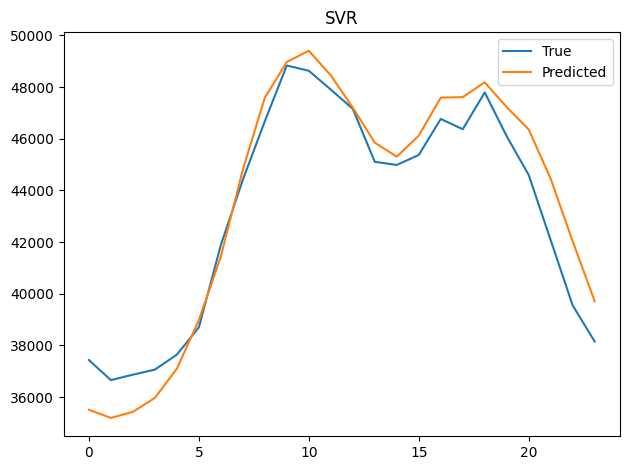

In [13]:
window = 24*multiplier
idx = np.random.randint(0, len(X_test) - window)

y_pred = model_svr.predict(X_test[idx:idx+window])

plt.plot(range(len(X_test[idx:idx+window])), y_test[idx:idx+window], label="True")
plt.plot(range(len(X_test[idx:idx+window])), y_pred, label="Predicted")
plt.title("SVR")
plt.legend()

plt.tight_layout()
plt.show()